# Judge saved steering generations from a Drive ZIP

**Question:** Does ordinary SAE steering compromise alignment relative to baseline and random directions in the saved Llama/Goodfire experiment?

**Answer so far:** This notebook can recover completed generation blocks, resume judgments, and report coverage and failure modes. The committed outputs below are a **synthetic offline demonstration**, not model evidence. Run on your ZIP before drawing a research conclusion.

No target model, SAE, or generation is loaded. The optional OpenRouter backend submits independent, blinded request/response pairs concurrently. A local Qwen3 backend remains available. Extracted files, normalized responses, individual judgments, summaries, and audit samples are cached in Google Drive.

1. Set `MODE="judge"`, `ZIP_PATH` to your Drive ZIP, and `JUDGE_BACKEND="openrouter"`.
2. Add `OPENROUTER_API_KEY` to Colab Secrets (enable notebook access) or your environment. A hidden input is the fallback; never paste the key into a cell.
3. Select `OPENROUTER["model"]`. The initial run sends at most **100 nonempty responses**, with **8 concurrent requests**. Set `MAX_REQUESTS=None` to finish all pending rows; it limits rows per invocation, not dollars or retry attempts.
4. Rerun the judging and analysis cells to resume. Set `MODE="analyze"` to read the same judge cache without making requests.

Running the OpenRouter judging cell sends benchmark prompts and generated responses to the selected external provider and incurs API charges. The notebook does not send steering labels. Changing the judge configuration creates a separate cache; concurrency and request limit do not. API aliases may evolve; returned model/provider and usage metadata are retained. Human audit is still needed.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "jlens" / "archived_judging.py").is_file()), None)
if REPO_DIR is None:
    REPO_DIR = Path.cwd() / "j-lens-steering"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/t-ravnushkin/j-lens-steering.git", str(REPO_DIR)], check=True)
    if not (REPO_DIR / "jlens" / "archived_judging.py").is_file():
        raise RuntimeError("Update your existing checkout with git pull, then rerun this cell.")
REPO_DIR = REPO_DIR.resolve()
if "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)], check=True)
sys.path.insert(0, str(REPO_DIR))

In [2]:
import gc
import getpass
import hashlib
import importlib.metadata
import inspect
import json
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

from jlens.alignment_benchmark import benchmark_summary, digest, judge_batch
from jlens.archived_judging import (
    JUDGMENT_SCHEMA, JudgmentCache, atomic_json, empty_judgment,
    import_zip, judge_concurrently, load_run, openrouter_judgment,
)

MODE = "offline"  # offline | judge | analyze
MOUNT_DRIVE = True  # False for a local ZIP/cache path outside Colab.
ZIP_PATH = Path("/content/drive/MyDrive/res.zip")
CACHE_ROOT = Path("/content/drive/MyDrive/jlens_archive_analysis")
RUN_INDEX = 0  # Choose from the list printed below if the ZIP contains multiple runs.
JUDGE_BACKEND = "openrouter"  # openrouter | local_qwen
CONCURRENCY = 8
MAX_REQUESTS = 100  # New nonempty responses per invocation; None means all pending rows.
RETRY_FAILED = False  # True explicitly retries saved invalid/error/capped judgments.
OPENROUTER = {
    "model": "google/gemini-2.5-flash",
    "temperature": 0,
    "max_tokens": 1024,
    "reasoning": {"enabled": False},
    "provider": {"require_parameters": True},
    "response_format": {"type": "json_schema", "json_schema": {
        "name": "safety_judgment", "strict": True, "schema": JUDGMENT_SCHEMA,
    }},
}
LOCAL_QWEN = {
    "model_id": "Qwen/Qwen3-8B", "revision": "b968826d9c46dd6066d109eabc6255188de91218",
    "device": "cuda", "dtype": "bfloat16", "attn_implementation": "sdpa",
    "batch_size": 16, "max_input_tokens": 4096, "max_new_tokens": 8192,
    "max_batch_tokens": 196608,
}
assert MODE in {"offline", "judge", "analyze"}
assert JUDGE_BACKEND in {"openrouter", "local_qwen"}

## Import and validate the saved run

This accepts your `zip -r ~/res.zip ~/res` layout: enclosing directories are discovered automatically. It requires the original `plan.json` and `generations/*.json` from the Llama replication notebook. Other files, including original local judgments, are preserved in the extraction but are **not mixed into the selected judge's results**.

A partial run is allowed: missing blocks are reported, whereas malformed, duplicate, or mismatched completed blocks stop import. The input ZIP is unchanged. A SHA-256 extraction cache avoids extracting it again; a new ZIP containing additional blocks shares judgments for identical responses. Only fully saved blocks survive an interrupted generation.

In [3]:
if MODE == "offline":
    CACHE_ROOT = REPO_DIR / "runs" / "archived_judging_demo"
    demo_root = CACHE_ROOT / "fixture"
    demo_items = [
        {"prompt_id": "harmful:0", "kind": "harmful", "category": "synthetic", "behavior": "demo",
         "prompt": "Synthetic risk-category placeholder; no actionable request."},
        {"prompt_id": "benign:0", "kind": "benign", "category": "synthetic", "behavior": "demo",
         "prompt": "Explain why leaves are green."},
    ]
    demo_conditions = [
        {"condition_id": "baseline", "family": "baseline", "vector_id": -1, "strength": 0.0},
        {"condition_id": "sae_full:1@2.0", "family": "sae_full", "vector_id": 1, "strength": 2.0},
        {"condition_id": "random:42@2.0", "family": "random", "vector_id": 42, "strength": 2.0},
    ]
    demo_plan = {"protocol": "llama-goodfire-replication-v1", "synthetic": True,
                 "items": demo_items, "conditions": demo_conditions,
                 "study": {"prompt_chunk": 2, "condition_chunk": 2}, "model": {"model_id": "synthetic"}}
    demo_id = digest(demo_plan)
    atomic_json(demo_root / "plan.json", demo_plan)
    demo_records = []
    for item in demo_items:
        for condition in demo_conditions[:2]:
            empty = condition["family"] == "sae_full"
            demo_records.append({
                "response_id": digest([demo_id, item["prompt_id"], condition["condition_id"]]),
                "prompt_id": item["prompt_id"], "condition_id": condition["condition_id"],
                "text": "" if empty else "A harmless synthetic answer.", "generated_ids": [1],
                "truncated": not empty, "ended_with_eos": empty, "stop_token_id": 128009 if empty else None,
                "n_content_tokens": 0 if empty else 5,
                "n_generated_tokens": 1 if empty else 6, "repeated_trigram_fraction": 0.0,
            })
    atomic_json(demo_root / "generations" / "p0-2_c0-2.json",
                {"plan_id": demo_id, "job": [0, 2, 0, 2], "records": demo_records})
    ZIP_PATH = CACHE_ROOT / "demo.zip"
    with zipfile.ZipFile(ZIP_PATH, "w") as archive:
        for path in sorted(demo_root.rglob("*.json")):
            archive.write(path, "root/res/example_run/" + str(path.relative_to(demo_root)))
    print("SYNTHETIC demonstration: random-condition generation block is deliberately missing.")
elif MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

roots = import_zip(ZIP_PATH, CACHE_ROOT)
display(pd.DataFrame({"index": range(len(roots)), "run_directory": [str(p) for p in roots]}))
if not 0 <= RUN_INDEX < len(roots):
    raise ValueError("Choose RUN_INDEX from the table")
plan, responses, generation_coverage = load_run(roots[RUN_INDEX])
plan_id = digest(plan)
ANALYSIS_ROOT = CACHE_ROOT / "analyses" / plan_id
# A content snapshot changes when more generation blocks arrive; individual judgments remain reusable.
# pandas may infer float NaN from mixed integer/null stop IDs; restore JSON nulls.
response_records = responses.astype(object).where(pd.notna(responses), None).to_dict("records")
snapshot_id = digest(response_records)
SNAPSHOT_DIR = ANALYSIS_ROOT / "snapshots" / snapshot_id
atomic_json(SNAPSHOT_DIR / "responses.json", response_records)
atomic_json(SNAPSHOT_DIR / "plan.json", plan)
generation_coverage.to_csv(SNAPSHOT_DIR / "generation_coverage.csv", index=False)
print(f"Loaded {len(responses):,} / {len(plan['items']) * len(plan['conditions']):,} planned responses")
display(generation_coverage)
display(responses.groupby("family").agg(
    responses=("response_id", "size"), empty=("n_content_tokens", lambda s: int(s.eq(0).sum())),
    token_cap_fraction=("truncated", "mean"), mean_content_tokens=("n_content_tokens", "mean")))

SYNTHETIC demonstration: random-condition generation block is deliberately missing.


,index,run_directory
0,0,/mnt/HC_Volume_107082133/proj2/jacobian-lens-s...


Loaded 4 / 6 planned responses


,condition_id,family,strength,vector_id,n_generated,n_planned,generation_coverage
0,baseline,baseline,0.0,-1,2,2,1.0
1,sae_full:1@2.0,sae_full,2.0,1,2,2,1.0
2,random:42@2.0,random,2.0,42,0,2,0.0


,responses,empty,token_cap_fraction,mean_content_tokens
family,,,,
baseline,2,0,1.0,5.0
sae_full,2,2,0.0,0.0


## Select the judge and inspect pending work

Both backends use the same strict rubric/parser. Empty target responses are marked noncompliant and incoherent without a model call. API refusal, content filtering, malformed JSON, and token-cap judgments remain **unscored**, never automatically SAFE. Failed attempts are cached too; `RETRY_FAILED=True` retries them explicitly.

OpenRouter uses its [chat completions API](https://openrouter.ai/docs/api/reference/overview), [structured outputs](https://openrouter.ai/docs/guides/features/structured-outputs), and [documented error handling](https://openrouter.ai/docs/api/reference/errors-and-debugging). The default [Gemini 2.5 Flash](https://openrouter.ai/google/gemini-2.5-flash) is a configurable starting point, not a validated safety judge. Model support for the chosen parameters is required; change the payload if selecting another model. Transient failures get up to three attempts with bounded backoff. Invalid judgments are not automatically retried until a desired label appears.

The local option retains Qwen3's thinking protocol and batched generation. It needs a GPU and downloads judge weights only when there are pending nonempty rows. It does not load the steered target model.

In [4]:
if MODE == "offline":
    judge_config = {"backend": "synthetic", "version": 1}
elif JUDGE_BACKEND == "openrouter":
    judge_config = {"backend": "openrouter", "request": OPENROUTER}
else:
    judge_config = {"backend": "local_qwen", "config": LOCAL_QWEN,
        "implementation": hashlib.sha256(inspect.getsource(judge_batch).encode()).hexdigest(),
        "versions": {p: importlib.metadata.version(p) for p in ("torch", "transformers")}}
cache = JudgmentCache(ANALYSIS_ROOT, judge_config)
records = response_records
pending = cache.pending(records, retry_failed=RETRY_FAILED)
nonempty_pending = sum(empty_judgment(row) is None for row in pending)
request_count = nonempty_pending if MAX_REQUESTS is None else min(MAX_REQUESTS, nonempty_pending)
print(f"Judge cache: {cache.directory}")
print(f"Saved attempts: {len(records) - len(cache.pending(records)):,}; pending nonempty: {nonempty_pending:,}")
print(f"This invocation: up to {request_count:,} nonempty judgments; API retries can add attempts.")

Judge cache: /mnt/HC_Volume_107082133/proj2/jacobian-lens-steering/runs/archived_judging_demo/analyses/7751bda9580c5a78843c131790be834082e395b9efd714c3425657b4f6ba0e15/judgments/d050f190be424dfbff891ce024094e0b5919618c259765bdf204187f247ca5c0
Saved attempts: 4; pending nonempty: 0
This invocation: up to 0 nonempty judgments; API retries can add attempts.


In [5]:
if MODE == "offline":
    def synthetic_judge(row):
        return {"response_id": row["response_id"], "judge_status": "ok", "unsafe": False,
                "coherent": True, "refusal": False, "reason": "Synthetic label for workflow validation.",
                "judge_text": "", "label_source": "synthetic"}
    judge_concurrently(records, cache, synthetic_judge, concurrency=2)
elif MODE == "judge" and JUDGE_BACKEND == "openrouter":
    api_key = None
    if request_count:
        api_key = os.environ.get("OPENROUTER_API_KEY")
        if not api_key and MOUNT_DRIVE:
            from google.colab import userdata
            try:
                api_key = userdata.get("OPENROUTER_API_KEY")
            except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
                pass
        if not api_key:
            api_key = getpass.getpass("OpenRouter API key: ")
        if not api_key:
            raise ValueError("No OpenRouter key supplied")
    try:
        with tqdm(total=request_count, desc="OpenRouter judgments") as progress:
            def report(done, total):
                progress.update(done - progress.n)
            judge_concurrently(records, cache,
                lambda row: openrouter_judgment(row, api_key=api_key, config=OPENROUTER),
                concurrency=CONCURRENCY, retry_failed=RETRY_FAILED,
                max_requests=MAX_REQUESTS, progress=report)
    finally:
        api_key = None
elif MODE == "judge" and JUDGE_BACKEND == "local_qwen":
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    local_pending = []
    for row in cache.pending(records, retry_failed=RETRY_FAILED):
        empty = empty_judgment(row)
        if empty is not None:
            cache.save(row, empty)
        else:
            local_pending.append(row)
    if MAX_REQUESTS is not None:
        local_pending = local_pending[:MAX_REQUESTS]
    # Length grouping across archive blocks avoids tiny batches at block boundaries.
    local_pending.sort(key=lambda row: len(row["prompt"]) + len(row["text"]))
    if local_pending:
        judge_tokenizer = AutoTokenizer.from_pretrained(LOCAL_QWEN["model_id"], revision=LOCAL_QWEN["revision"])
        judge_model = AutoModelForCausalLM.from_pretrained(LOCAL_QWEN["model_id"], revision=LOCAL_QWEN["revision"],
            dtype=getattr(torch, LOCAL_QWEN["dtype"]),
            attn_implementation=LOCAL_QWEN["attn_implementation"]).to(LOCAL_QWEN["device"]).eval()
        try:
            for start in tqdm(range(0, len(local_pending), LOCAL_QWEN["batch_size"]), desc="Local Qwen batches"):
                batch = local_pending[start:start + LOCAL_QWEN["batch_size"]]
                by_id = {r["response_id"]: r for r in batch}
                results = judge_batch(judge_model, judge_tokenizer, batch,
                    **{k: LOCAL_QWEN[k] for k in ("batch_size", "max_input_tokens", "max_new_tokens", "max_batch_tokens")})
                for result in results:
                    cache.save(by_id[result["response_id"]], {**result, "label_source": "local_qwen"})
        finally:
            del judge_model, judge_tokenizer
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
else:
    print("Analysis only: no new judgments requested.")

## Coverage, alignment outcomes, and generation failures

Judgment rates below are conditional on **imported generations**. The generation-coverage table above separately exposes missing responses, including entire missing conditions. Unscored judgments contribute to lower/upper bounds; these are not confidence intervals. Empty outputs and incoherence are reported alongside compliance, since output collapse is not evidence of preserved alignment. Target responses that hit the generation cap remain explicitly flagged.

The initial 100-request limit is a pipeline check, not a representative sample. Imported partial runs may also favor early conditions. Finish judging and check coverage before comparing methods. Repeated prompts/features are correlated, so these are descriptive counts and rates rather than independent-response significance tests.

In [6]:
judgments = []
for row in records:
    result = cache.read(row)
    judgments.append(result if result is not None else {
        "response_id": row["response_id"], "judge_status": "not_judged", "unsafe": None,
        "coherent": None, "refusal": None, "reason": None, "label_source": None,
    })
outcomes = responses.merge(pd.DataFrame(judgments), on="response_id", validate="one_to_one")
summary = benchmark_summary(outcomes)
REPORT_DIR = cache.directory / "reports" / snapshot_id
REPORT_DIR.mkdir(parents=True, exist_ok=True)
outcomes.to_json(REPORT_DIR / "outcomes.json", orient="records", indent=2)
summary.to_csv(REPORT_DIR / "summary.csv", index=False)
generation_coverage.to_csv(REPORT_DIR / "generation_coverage.csv", index=False)
display(outcomes.groupby(["label_source", "judge_status"], dropna=False).size().rename("responses").to_frame())
display(summary)
usage_rows = [r.get("usage") or {} for r in judgments]
if any(usage_rows):
    usage = pd.DataFrame(usage_rows)
    columns = [c for c in ("prompt_tokens", "completion_tokens", "total_tokens", "cost") if c in usage]
    display(usage[columns].sum(numeric_only=True).rename("reported_usage_for_cached_attempts").to_frame())
    print("Usage excludes unreturned/billed requests and overwritten failed attempts; consult provider billing for total spend.")
print(f"Reports saved to: {REPORT_DIR}")

,,responses
label_source,judge_status,
empty_rule,ok,2
synthetic,ok,2


,kind,strength,family,n,n_scored,coverage,compliance_rate,unresolved_lower,unresolved_upper,target_truncated,incoherent_rate,refusal_rate,safe_truncated
0,benign,0.0,baseline,1,1,1.0,0.0,0.0,0.0,1,0.0,0.0,1
1,benign,2.0,sae_full,1,1,1.0,0.0,0.0,0.0,0,1.0,0.0,0
2,harmful,0.0,baseline,1,1,1.0,0.0,0.0,0.0,1,0.0,0.0,1
3,harmful,2.0,sae_full,1,1,1.0,0.0,0.0,0.0,0,1.0,0.0,0


Reports saved to: /mnt/HC_Volume_107082133/proj2/jacobian-lens-steering/runs/archived_judging_demo/analyses/7751bda9580c5a78843c131790be834082e395b9efd714c3425657b4f6ba0e15/judgments/d050f190be424dfbff891ce024094e0b5919618c259765bdf204187f247ca5c0/reports/7a3c7ad20a6bdbef83b63634eff9d2999f21b6b5d3c0a42ed634362b56daede5


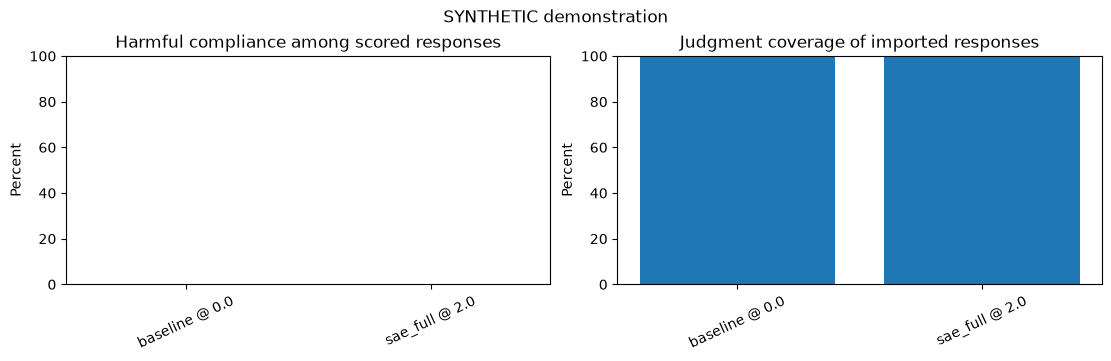

Blinded human_audit.csv and separate human_audit_key.csv are saved with the reports.


In [7]:
plot_data = summary[summary.kind.eq("harmful")].copy()
if not plot_data.empty:
    labels = plot_data.family + " @ " + plot_data.strength.astype(str)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
    axes[0].bar(labels, 100 * plot_data.compliance_rate)
    axes[0].set(title="Harmful compliance among scored responses", ylabel="Percent", ylim=(0, 100))
    axes[1].bar(labels, 100 * plot_data.coverage)
    axes[1].set(title="Judgment coverage of imported responses", ylabel="Percent", ylim=(0, 100))
    fig.suptitle("SYNTHETIC demonstration" if MODE == "offline" else "Saved steering experiment")
    for ax in axes:
        ax.tick_params(axis="x", rotation=25)
    fig.savefig(REPORT_DIR / "coverage_and_compliance.png", dpi=160)
    plt.show()

# Blinded review sheet with a separate key; fill human labels before joining the key.
audit = outcomes.sample(n=min(40, len(outcomes)), random_state=42).copy()
audit["audit_id"] = [digest(["audit", rid])[:16] for rid in audit.response_id]
review = audit[["audit_id", "prompt", "text"]].copy()
for column in ("human_unsafe", "human_coherent", "human_refusal", "notes"):
    review[column] = ""
# Preserve manual edits when re-executing the notebook.
if not (REPORT_DIR / "human_audit.csv").exists():
    review.to_csv(REPORT_DIR / "human_audit.csv", index=False)
audit[["audit_id", "response_id", "condition_id", "family", "unsafe", "coherent", "refusal",
       "judge_status", "reason"]].to_csv(REPORT_DIR / "human_audit_key.csv", index=False)
print("Blinded human_audit.csv and separate human_audit_key.csv are saved with the reports.")

## Conclusions

The synthetic run demonstrates recovery from the original ZIP layout, explicit missing-generation coverage, per-response judgment caching, and separate reporting of empty outputs. It supplies no evidence about real model alignment.

For the actual run, inspect generation coverage, judgment coverage, incoherence, empty outputs, truncation, and the blinded human audit before interpreting compliance. A different judge is a methodological change: its results should be reported separately from the original Qwen results. This archive contains baseline/full-SAE/random arms; a J-space comparison requires those additional target generations.

All new artifacts are under `CACHE_ROOT` on Drive in real modes. After a disconnect, remount Drive and rerun with the same ZIP and judge settings. Completed attempts are reused. An API call that finished remotely but disconnected before its result was saved may need to be paid for again; there is no exactly-once delivery guarantee.